Histogram saved to: C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\CD2AP_BE_DwellTimeHistograms.png


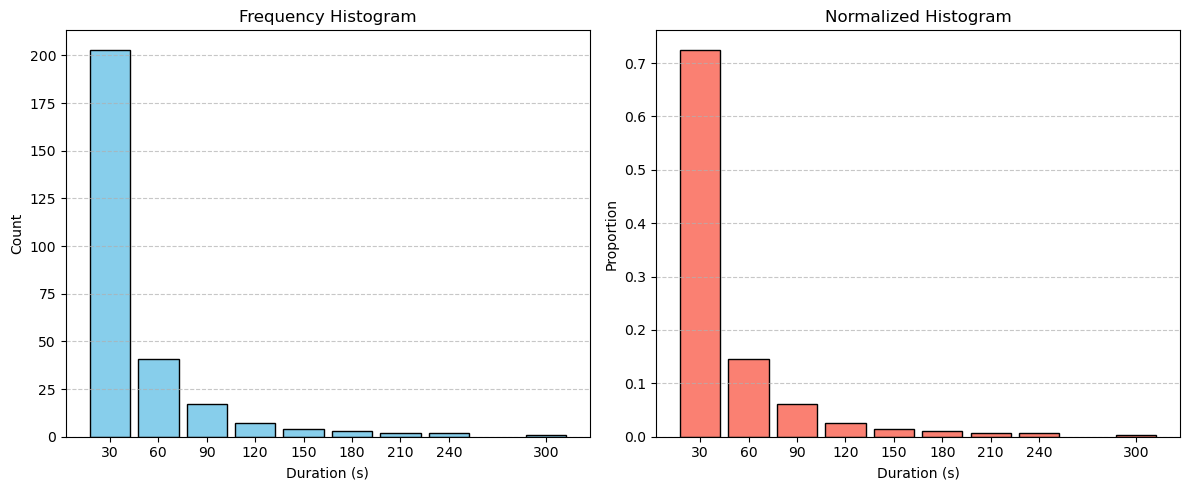

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os

# Function to count interconversions and calculate durations (no filtering)
def analyze_sequence(sequence, time_interval_seconds=30):
    # Step 1: Compute differences
    differences = [sequence[i] - sequence[i - 1] for i in range(1, len(sequence))]
    
    # Step 2: Determine signs
    signs = [1 if x > 0 else -1 if x < 0 else 0 for x in differences]
    
    # Step 3: Identify interconversion points (no filtering)
    change_indices = [i + 1 for i in range(1, len(signs)) if signs[i] != signs[i - 1]]
    
    # Step 4: Calculate durations between changes
    durations = [change_indices[i] - change_indices[i - 1] for i in range(1, len(change_indices))]
    
    # Step 5: Convert to time using interval
    durations_sec = [d * time_interval_seconds for d in durations]
    
    return len(change_indices), change_indices, durations_sec

# Master list to collect all durations across identifiers
all_durations_across_all = []

# Function to process the Excel file and generate results
def process_excel_with_full_output(input_file, output_file_summary, output_file_durations, time_interval_seconds=30):
    data = pd.read_excel(input_file)
    time_points = data.iloc[:, 0]
    data_columns = data.iloc[:, 1:]

    results = {
        "Identifier": [],
        "Interconversion Count": [],
        "Change Indices": [],
        "Durations (s)": [],
        "Average Duration (s)": []
    }

    for column in data_columns.columns:
        sequence = data[column].dropna().tolist()
        interconversion_count, change_indices, durations_sec = analyze_sequence(sequence, time_interval_seconds)
        
        results["Identifier"].append(column)
        results["Interconversion Count"].append(interconversion_count)
        results["Change Indices"].append(change_indices)
        results["Durations (s)"].append(durations_sec)
        results["Average Duration (s)"].append(round(sum(durations_sec) / len(durations_sec), 2) if durations_sec else 0)

        all_durations_across_all.extend(durations_sec)

    # Save summary output
    summary_df = pd.DataFrame(results)
    summary_df.to_excel(output_file_summary, index=False)

    # Save durations in second file
    duration_df = pd.DataFrame({"Duration (s)": all_durations_across_all})
    duration_df.to_excel(output_file_durations, index=False)
    

# Plot histogram
    duration_counts = Counter(all_durations_across_all)
    sorted_durations = sorted(duration_counts.keys())
    frequencies = [duration_counts[d] for d in sorted_durations]
    total = sum(frequencies)
    normalized_frequencies = [f / total for f in frequencies]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Frequency histogram
    axs[0].bar(sorted_durations, frequencies, width=25, color='skyblue', edgecolor='black')
    axs[0].set_title("Frequency Histogram")
    axs[0].set_xlabel("Duration (s)")
    axs[0].set_ylabel("Count")
    axs[0].set_xticks(sorted_durations)
    axs[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Normalized histogram
    axs[1].bar(sorted_durations, normalized_frequencies, width=25, color='salmon', edgecolor='black')
    axs[1].set_title("Normalized Histogram")
    axs[1].set_xlabel("Duration (s)")
    axs[1].set_ylabel("Proportion")
    axs[1].set_xticks(sorted_durations)
    axs[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()

    # Save the figure here
    output_hist_path = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\CD2AP_BE_DwellTimeHistograms.png'
    fig.savefig(output_hist_path, dpi=300)
    print(f"Histogram saved to: {output_hist_path}")

    plt.show()

# Example file paths (replace with your actual paths)
input_excel = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\subunit_data_CD2AP_BE.xlsx'
output_summary = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\CD2AP_BE_DwellTimesOutput.xlsx'
output_durations = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\CD2AP_BE_AllDwellTimes.xlsx'

# Run the full analysis
process_excel_with_full_output(input_excel, output_summary, output_durations, time_interval_seconds=30)
